# 🧪 Experiment 10: Speculative Decoding Experiments

This notebook explores Speculative Decoding in MLX, utilizing a small draft model to accelerate generation from a large target model.

### The Research Tracks
1. **Track A (Standard):** Using a smaller model (Llama-3.2-1B) to draft for a larger model (Llama-3-8B).
2. **Track B (Noisy Drafts):** Using a physically corrupted version of the target model as a draft to measure structural integrity boundaries.

In [1]:
import mlx.core as mx
from mlx_lm import load, generate
import time

def measure_generation(model, tokenizer, prompt, draft_model=None, max_tokens=100):
    messages = [{"role": "user", "content": prompt}]
    formatted_prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    start_time = time.perf_counter()
    # verbose=True will print out tokens/sec and acceptance rates natively in mlx_lm
    response = generate(
        model,
        tokenizer,
        prompt=formatted_prompt,
        draft_model=draft_model,
        max_tokens=max_tokens,
        verbose=False  # Turned off to reduce noise, since we calculate it below
    )
    end_time = time.perf_counter()
    
    # Calculate tokens per second
    num_tokens = len(tokenizer.encode(response))
    total_time = end_time - start_time
    tokens_per_sec = num_tokens / total_time
    
    print(f"Generated {num_tokens} tokens in {total_time:.2f} seconds | Speed: {tokens_per_sec:.2f} tok/sec")
    return response, tokens_per_sec

### Track A: Standard Speculative Decoding
Loading the Target Model (Llama-3-8B) and the Draft Model (Llama-3.2-1B).

In [2]:
target_id = "mlx-community/Meta-Llama-3-8B-Instruct-4bit"
draft_id = "mlx-community/Llama-3.2-1B-Instruct-4bit"

print(f"Loading Target Model: {target_id}")
target_model, tokenizer = load(target_id)

print(f"\nLoading Draft Model: {draft_id}")
draft_model, _ = load(draft_id)

Loading Target Model: mlx-community/Meta-Llama-3-8B-Instruct-4bit


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]


Loading Draft Model: mlx-community/Llama-3.2-1B-Instruct-4bit


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

In [3]:
prompt = "Explain the concept of speculative decoding in large language models. Be concise but technical."

print("=== Generation WITHOUT Draft Model ===")
_, speed_no_draft = measure_generation(target_model, tokenizer, prompt, max_tokens=150)

print("\n=== Generation WITH Draft Model ===")
_, speed_with_draft = measure_generation(target_model, tokenizer, prompt, draft_model=draft_model, max_tokens=150)

=== Generation WITHOUT Draft Model ===
Generated 150 tokens in 10.13 seconds | Speed: 14.81 tok/sec

=== Generation WITH Draft Model ===
Generated 150 tokens in 7.42 seconds | Speed: 20.21 tok/sec


### Track B: Noisy Drafts (Weight Surgery)
Here, we duplicate the target model and perturb its `lm_head.weight`. We will see how acceptance rate degrades as the draft model gets noisier.

In [4]:
import copy
import gc

print("Freeing memory from Track A (1B Draft Model)...")
if "draft_model" in locals():
    del draft_model
    gc.collect()
    mx.metal.clear_cache()

print("Creating Noisy Draft by shallow copying the Target Model...")
# Shallow copy the model to share transformer weights, but duplicate the lm_head
noisy_draft_model = copy.copy(target_model)
noisy_draft_model.lm_head = copy.copy(target_model.lm_head)

original_draft_weight = mx.array(noisy_draft_model.lm_head.weight)

def corrupt_draft(shift_amount):
    """
    Corrupts the lm_head of the noisy draft model in-place.
    """
    if shift_amount == 0:
        noisy_draft_model.lm_head.weight = mx.array(original_draft_weight)
    else:
        corrupted_weight = (original_draft_weight.astype(mx.int64) - shift_amount).astype(mx.uint32)
        noisy_draft_model.lm_head.weight = mx.array(corrupted_weight)
    
    # Force MLX to evaluate the new weight tensor
    mx.eval(noisy_draft_model.lm_head.weight)
    print(f"Draft Model Corrupted with shift: {shift_amount}")
    print(f"First weight element verification: {hex(noisy_draft_model.lm_head.weight.reshape(-1)[0].item())}")

Freeing memory from Track A (1B Draft Model)...
Creating Noisy Draft by shallow copying the Target Model...


mx.metal.clear_cache is deprecated and will be removed in a future version. Use mx.clear_cache instead.



Testing Noisy Draft with Shift = 0
Draft Model Corrupted with shift: 0
First weight element verification: 0x5091b698
Generated 100 tokens in 6.76 seconds | Speed: 14.80 tok/sec

Testing Noisy Draft with Shift = 500000
Draft Model Corrupted with shift: 500000
First weight element verification: 0x508a1578
Generated 100 tokens in 16.12 seconds | Speed: 6.20 tok/sec

Testing Noisy Draft with Shift = 1000000
Draft Model Corrupted with shift: 1000000
First weight element verification: 0x50827458
Generated 100 tokens in 14.04 seconds | Speed: 7.12 tok/sec

Testing Noisy Draft with Shift = 2000000
Draft Model Corrupted with shift: 2000000
First weight element verification: 0x50733218
Generated 100 tokens in 25.89 seconds | Speed: 3.86 tok/sec

Testing Noisy Draft with Shift = 3000000
Draft Model Corrupted with shift: 3000000
First weight element verification: 0x5063efd8
Generated 100 tokens in 25.45 seconds | Speed: 3.93 tok/sec

=== Results Summary ===
Shift        0: 14.80 tok/sec
Shift   5

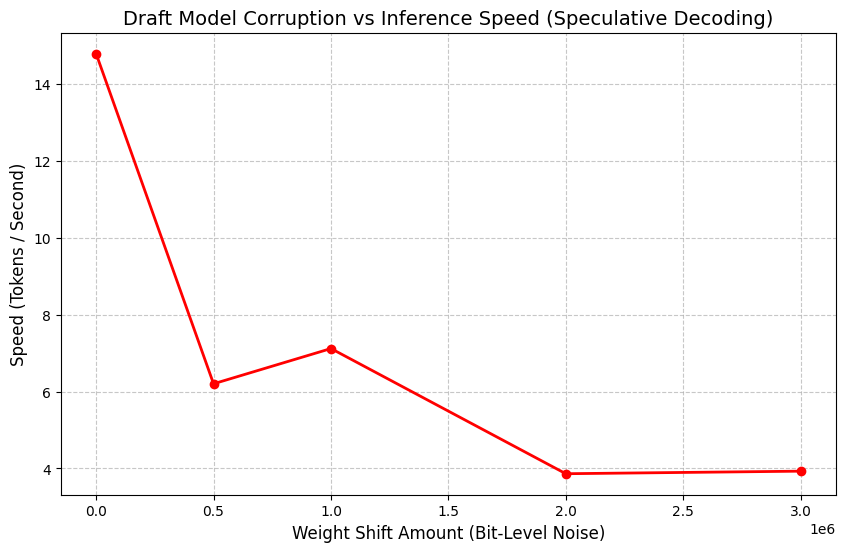

In [5]:
import matplotlib.pyplot as plt

prompt_noisy = "Write a short poem about a neural network learning to read."

shifts_to_test = [0, 500000, 1000000, 2000000, 3000000]
speeds = []

for shift in shifts_to_test:
    print(f"\n{"="*40}\nTesting Noisy Draft with Shift = {shift}\n{"="*40}")
    corrupt_draft(shift)
    _, speed = measure_generation(target_model, tokenizer, prompt_noisy, draft_model=noisy_draft_model, max_tokens=100)
    speeds.append(speed)

print("\n=== Results Summary ===")
for shift, speed in zip(shifts_to_test, speeds):
    print(f"Shift {shift:>8}: {speed:.2f} tok/sec")

# Plot the degradation
plt.figure(figsize=(10, 6))
plt.plot(shifts_to_test, speeds, marker="o", linestyle="-", color="r", linewidth=2)
plt.title("Draft Model Corruption vs Inference Speed (Speculative Decoding)", fontsize=14)
plt.xlabel("Weight Shift Amount (Bit-Level Noise)", fontsize=12)
plt.ylabel("Speed (Tokens / Second)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

### Bonus: Visualizing the Acceptance Mechanism
To truly understand how the target model verifies the draft model, let us write a simplified, custom greedy speculative decoding step. This will explicitly print the draft model predictions and show whether the target model accepts or rejects them. We will compare a pristine draft model to our noisy, corrupted draft.

In [6]:
def visualize_speculative_step(target_model, draft_model, prompt_tokens, K=5):
    draft_tokens = []
    draft_seq = prompt_tokens.copy()
    
    print("1. DRAFTING PHASE (Small/Draft Model):")
    for i in range(K):
        logits = draft_model(mx.array([draft_seq]))
        next_token = mx.argmax(logits[0, -1, :]).item()
        draft_seq.append(next_token)
        draft_tokens.append(next_token)
        print(f"   Proposed Token {i+1}: \"{tokenizer.decode([next_token])}\" (ID: {next_token})")
        
    print("\n2. VERIFICATION PHASE (Large/Target Model):")
    eval_seq = prompt_tokens + draft_tokens
    target_logits = target_model(mx.array([eval_seq]))
    
    accepted_tokens = []
    L = len(prompt_tokens)
    
    for i in range(K):
        target_pred = mx.argmax(target_logits[0, L - 1 + i, :]).item()
        draft_tok = draft_tokens[i]
        
        if target_pred == draft_tok:
            print(f"   [ACCEPTED] Position {i+1}! Target agreed on \"{tokenizer.decode([draft_tok])}\"")
            accepted_tokens.append(draft_tok)
        else:
            print(f"   [REJECTED] Position {i+1}! Draft said \"{tokenizer.decode([draft_tok])}\", Target wanted \"{tokenizer.decode([target_pred])}\"")
            print("   -> Truncating remaining draft tokens...")
            accepted_tokens.append(target_pred)
            break
            
    return accepted_tokens

test_prompt = "The Apollo 11 mission was the first to"
prompt_tokens = tokenizer.encode(test_prompt)

print("=== SCENARIO A: Pristine Draft Model ===")
pristine_draft, _ = load("mlx-community/Llama-3.2-1B-Instruct-4bit")
accepted_pristine = visualize_speculative_step(target_model, pristine_draft, prompt_tokens, K=5)
print(f"\nResulting text chunk: \"{tokenizer.decode(accepted_pristine)}\"")

print("\n\n=== SCENARIO B: Noisy Draft Model (Shift = 1000000) ===")
corrupt_draft(1000000)
accepted_noisy = visualize_speculative_step(target_model, noisy_draft_model, prompt_tokens, K=5)
print(f"\nResulting text chunk: \"{tokenizer.decode(accepted_noisy)}\"")

=== SCENARIO A: Pristine Draft Model ===


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

1. DRAFTING PHASE (Small/Draft Model):
   Proposed Token 1: " land" (ID: 4363)
   Proposed Token 2: " humans" (ID: 12966)
   Proposed Token 3: " on" (ID: 389)
   Proposed Token 4: " the" (ID: 279)
   Proposed Token 5: " Moon" (ID: 17781)

2. VERIFICATION PHASE (Large/Target Model):
   [ACCEPTED] Position 1! Target agreed on " land"
   [ACCEPTED] Position 2! Target agreed on " humans"
   [ACCEPTED] Position 3! Target agreed on " on"
   [ACCEPTED] Position 4! Target agreed on " the"
   [ACCEPTED] Position 5! Target agreed on " Moon"

Resulting text chunk: " land humans on the Moon"


=== SCENARIO B: Noisy Draft Model (Shift = 1000000) ===
Draft Model Corrupted with shift: 1000000
First weight element verification: 0x50827458
1. DRAFTING PHASE (Small/Draft Model):
   Proposed Token 1: " land" (ID: 4363)
   Proposed Token 2: " human" (ID: 3823)
   Proposed Token 3: ".scalablytyped" (ID: 82000)
   Proposed Token 4: " erotik" (ID: 28662)
   Proposed Token 5: " vrou" (ID: 23259)

2. VERIFICAT